# Análisis exploratorio

## Librerías y carga

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import ast
import re
import unicodedata

from collections import Counter
from itertools import combinations
from scipy.stats import pearsonr, spearmanr

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 90)

sns.set_theme(style="whitegrid", palette="colorblind")

videos = pd.read_csv(
    "data/youtube_videos_clean.csv",
    encoding="utf-8-sig"
)

comments = pd.read_csv(
    "data/youtube_comments_clean.csv",
    encoding="utf-8-sig"
)

print(f"Videos: {videos.shape}")
print(f"Comentarios: {comments.shape}")

Videos: (293, 21)
Comentarios: (406, 24)


## Validación

In [2]:
print("Duplicados")
print(f"video_id duplicados:   {videos['video_id'].duplicated().sum()}")
print(f"comment_id duplicados: {comments['comment_id'].duplicated().sum()}")

print("\nValores faltantes principales en videos:")
display(
    videos.isna()
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .to_frame("faltantes")
)

print("\nValores faltantes principales en comentarios:")
display(
    comments.isna()
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .to_frame("faltantes")
)

Duplicados
video_id duplicados:   0
comment_id duplicados: 0

Valores faltantes principales en videos:


,faltantes
description,26
description_snippet,25
published_time,13
view_count_text,13
view_count_text_parsed,13
source_group,0
dataset_sources,0
channel_handle,0
source_query,0
channel_id,0



Valores faltantes principales en comentarios:


,faltantes
viewer_rating,406
hashtags,405
mentions,401
emojis,345
texto_limpio,6
comment_id,0
texto_original,0
like_count,0
author_handle_decoded,0
is_pinned,0


## Indicadores generales

In [3]:
resumen_general = pd.Series({
    "Videos únicos": videos["video_id"].nunique(),
    "Canales únicos": videos["channel_id"].nunique(),
    "Comentarios únicos": comments["comment_id"].nunique(),
    "Autores únicos": comments["author_channel_id"].nunique(),
    "Videos con comentarios recolectados": comments["video_id"].nunique(),
    "Canales con comentarios recolectados": comments["channel_id"].nunique(),
    "Me gusta en comentarios": comments["like_count"].sum(),
    "Respuestas registradas": comments["reply_count"].sum(),
    "Categorías": videos["category"].nunique()
}).to_frame("resultado")

display(resumen_general)

videos_con_comentarios = comments["video_id"].nunique()
cobertura = videos_con_comentarios / videos["video_id"].nunique()

print(
    f"\nLos comentarios recolectados cubren "
    f"{videos_con_comentarios} de {videos['video_id'].nunique()} videos "
    f"({cobertura:.1%})."
)

,resultado
Videos únicos,293
Canales únicos,97
Comentarios únicos,406
Autores únicos,332
Videos con comentarios recolectados,19
Canales con comentarios recolectados,8
Me gusta en comentarios,2325
Respuestas registradas,51
Categorías,11



Los comentarios recolectados cubren 19 de 293 videos (6.5%).


## Videos por canal

,channel_id,channel_name,videos
3,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala,32
54,UCXa6LVjBzUtmcM3cwbd9e2w,Municipalidad de Guatemala,27
26,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,18
28,UCEepOY2svuxbsJ-zsAPT9Fg,PrensaLibreOficial,17
15,UC8u2nvyHewt-mjdWSj0HJmQ,Ministerio de Gobernación,14
17,UCAutgrPkiLhZxTB-Ujje1fw,CIV -Ministerio de Comunicaciones,11
63,UCaivrAhro2BpsJdrPe-IyRg,Diario de Centro América,11
34,UCHsYnV67K3J0yJ4QeciVCww,PNCdeGuatemala,10
52,UCW_PHqwqCCalvQGOEsVU0jw,Concejales de Oposición - Muni Guate,10
7,UC6SA1dVHvAkc6yNS_t5cbGw,Conred,8



Descripción de videos por canal:


,count,mean,std,min,25%,50%,75%,max
videos,97.0,3.020619,5.141699,1.0,1.0,1.0,2.0,32.0


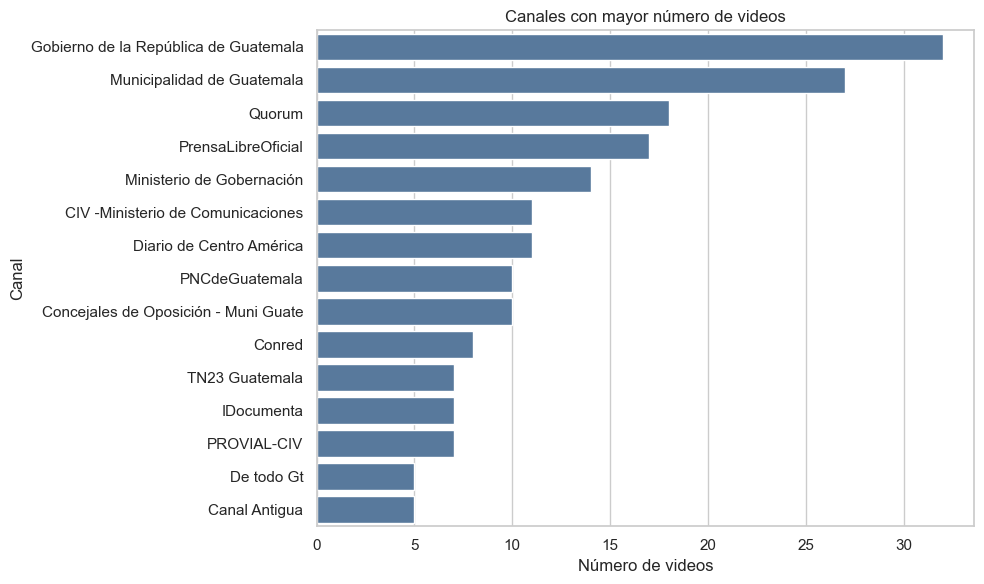

In [4]:
videos_por_canal = (
    videos.groupby(["channel_id", "channel_name"])
    .agg(videos=("video_id", "nunique"))
    .reset_index()
    .sort_values("videos", ascending=False)
)

display(videos_por_canal.head(15))

print("\nDescripción de videos por canal:")
display(videos_por_canal["videos"].describe().to_frame().T)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=videos_por_canal.head(15),
    x="videos",
    y="channel_name",
    color="#4C78A8"
)

plt.title("Canales con mayor número de videos")
plt.xlabel("Número de videos")
plt.ylabel("Canal")
plt.tight_layout()
plt.show()

## Comentarios y autores por video

In [5]:
participacion_video = (
    comments.groupby(["video_id", "video_title", "channel_name"])
    .agg(
        comentarios=("comment_id", "nunique"),
        autores_unicos=("author_channel_id", "nunique"),
        me_gusta=("like_count", "sum"),
        respuestas=("reply_count", "sum")
    )
    .reset_index()
)

participacion_video = participacion_video.merge(
    videos[
        [
            "video_id",
            "view_count",
            "category",
            "source_query",
            "video_url"
        ]
    ],
    on="video_id",
    how="left"
)

participacion_video = participacion_video.sort_values(
    ["comentarios", "autores_unicos"],
    ascending=False
)

display(participacion_video.head(15))

print("\nDescripción considerando únicamente videos con comentarios:")
display(
    participacion_video[
        ["comentarios", "autores_unicos", "me_gusta", "respuestas"]
    ].describe().T
)

,video_id,video_title,channel_name,comentarios,autores_unicos,me_gusta,respuestas,view_count,category,source_query,video_url
14,n8iP75gIpmw,Qué rico come tu diputado,Quorum,161,128,358,3,11775,News & Politics,Quorum GT,https://www.youtube.com/watch?v=n8iP75gIpmw
12,j43HgwYFKfk,La cooptación de Walter Mazariegos en la USAC,Quorum,50,49,91,0,10156,News & Politics,@quorumgt,https://www.youtube.com/watch?v=j43HgwYFKfk
2,6W4u8sGEnGM,Inician los trabajos de recuperación del Puente Belice II.,Gobierno de la República de Guatemala,45,32,90,11,11670,Entertainment,Gobierno de la República de Guatemala,https://www.youtube.com/watch?v=6W4u8sGEnGM
13,lj983NWyAQY,Plan 2032 Ciudad de Guatemala,Municipalidad de Guatemala,25,25,1697,16,304089,News & Politics,Municipalidad de Guatemala,https://www.youtube.com/watch?v=lj983NWyAQY
5,PjmxCj-a9Hg,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,Gobierno de la República de Guatemala,25,19,20,4,3628,Entertainment,@GobiernodeGuatemala,https://www.youtube.com/watch?v=PjmxCj-a9Hg
4,OkXlHx0hx-8,EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticia...,Noticias Telemundo,25,18,25,13,14200,News & Politics,guatemala noticias,https://www.youtube.com/watch?v=OkXlHx0hx-8
17,yLZS3JiEBg8,Arroz con pollo a la MONOPOLIO,Quorum,16,16,13,0,1954,News & Politics,@quorumgt/videos,https://www.youtube.com/watch?v=yLZS3JiEBg8
0,06mFNPU0aB8,Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer asalto,Noti7,14,13,12,1,6692,News & Politics,guatemala noticias,https://www.youtube.com/watch?v=06mFNPU0aB8
15,ndAZjHqzzT8,Internet: escoger el menos malo,Quorum,12,10,3,1,717,News & Politics,@quorumgt/videos,https://www.youtube.com/watch?v=ndAZjHqzzT8
10,b_Hkrkl3adA,Bloqueos en Guatemala este 31 de agosto por alza en combustibles afectan rutas princip...,PrensaLibreOficial,7,7,1,1,5469,News & Politics,guatemala noticias,https://www.youtube.com/watch?v=b_Hkrkl3adA



Descripción considerando únicamente videos con comentarios:


,count,mean,std,min,25%,50%,75%,max
comentarios,19.0,21.368421,36.824223,1.0,2.5,7.0,25.0,161.0
autores_unicos,19.0,18.052632,29.457076,1.0,2.5,7.0,18.5,128.0
me_gusta,19.0,122.368421,390.247815,0.0,0.5,4.0,22.5,1697.0
respuestas,19.0,2.684211,4.933476,0.0,0.0,0.0,2.0,16.0


## Gráfica de participación por video

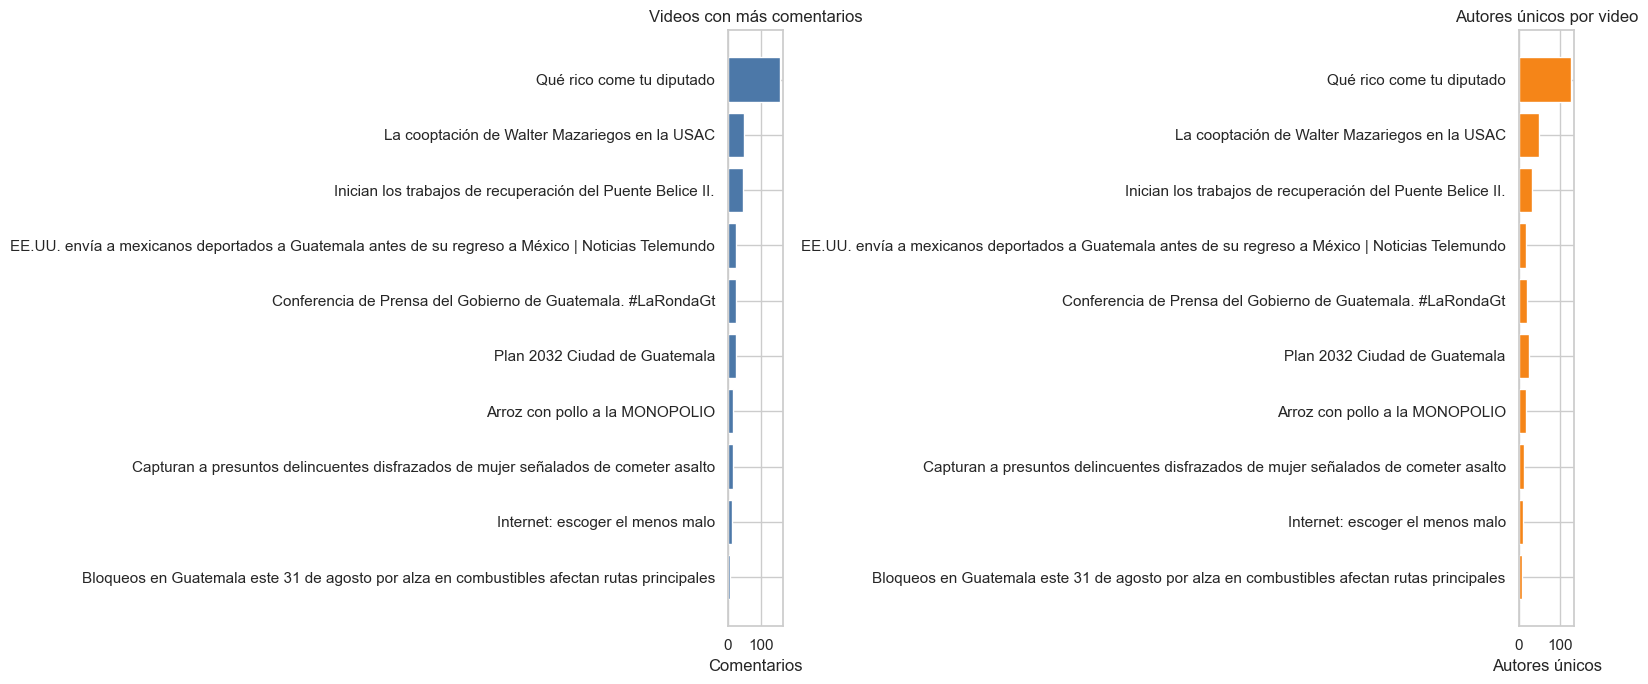

In [6]:
top_videos = participacion_video.head(10).sort_values(
    "comentarios",
    ascending=True
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 7)
)

axes[0].barh(
    top_videos["video_title"],
    top_videos["comentarios"],
    color="#4C78A8"
)

axes[0].set_title("Videos con más comentarios")
axes[0].set_xlabel("Comentarios")
axes[0].set_ylabel("")

axes[1].barh(
    top_videos["video_title"],
    top_videos["autores_unicos"],
    color="#F58518"
)

axes[1].set_title("Autores únicos por video")
axes[1].set_xlabel("Autores únicos")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## Participación por canal

,channel_id,channel_name,comentarios,autores_unicos,videos_comentados,me_gusta,respuestas,porcentaje_comentarios
1,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,256,214,11,480,4,0.630542
0,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala,70,50,2,110,15,0.172414
3,UCRwA1NUcUnwsly35ikGhp0A,Noticias Telemundo,25,18,1,25,13,0.061576
5,UCXa6LVjBzUtmcM3cwbd9e2w,Municipalidad de Guatemala,25,25,1,1697,16,0.061576
4,UCVpSRoZgngfSL03Nlbjtq9A,Noti7,14,13,1,12,1,0.034483
2,UCEepOY2svuxbsJ-zsAPT9Fg,PrensaLibreOficial,7,7,1,1,1,0.017241
7,UCt5Dw7ePnn0AqPqRF8Xpjkw,TN23 Guatemala,7,7,1,0,1,0.017241
6,UCdSVqHGHzyMTXSafUHY-e-w,Noticiero Guatevisión 13 Hrs.,2,2,1,0,0,0.004926


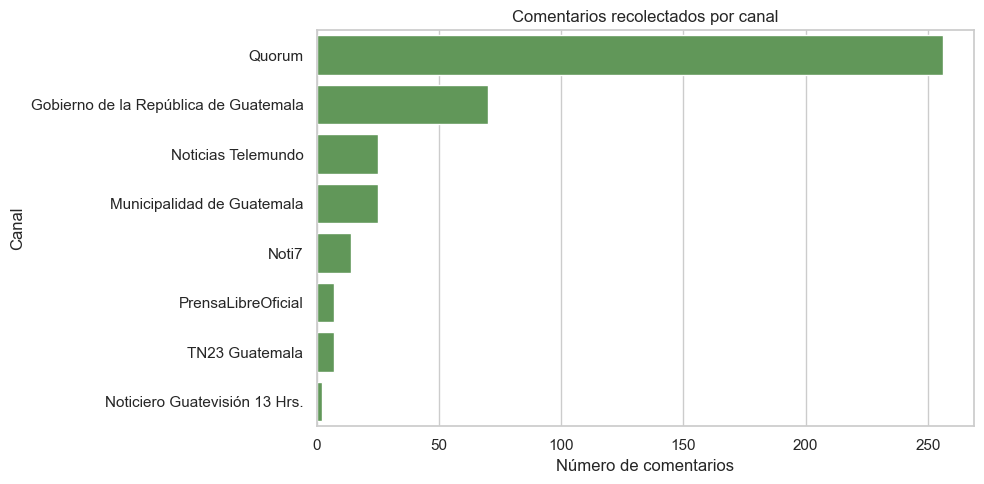

In [7]:
participacion_canal = (
    comments.groupby(["channel_id", "channel_name"])
    .agg(
        comentarios=("comment_id", "nunique"),
        autores_unicos=("author_channel_id", "nunique"),
        videos_comentados=("video_id", "nunique"),
        me_gusta=("like_count", "sum"),
        respuestas=("reply_count", "sum")
    )
    .reset_index()
    .sort_values("comentarios", ascending=False)
)

participacion_canal["porcentaje_comentarios"] = (
    participacion_canal["comentarios"]
    / participacion_canal["comentarios"].sum()
)

display(participacion_canal)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=participacion_canal,
    x="comentarios",
    y="channel_name",
    color="#59A14F"
)

plt.title("Comentarios recolectados por canal")
plt.xlabel("Número de comentarios")
plt.ylabel("Canal")
plt.tight_layout()
plt.show()

## Categorías y consultas

,categoria,videos
0,News & Politics,138
1,People & Blogs,66
2,Entertainment,48
3,Education,19
4,Travel & Events,8
5,Science & Technology,6
6,Nonprofits & Activism,3
7,Film & Animation,2
8,Comedy,1
9,Sports,1


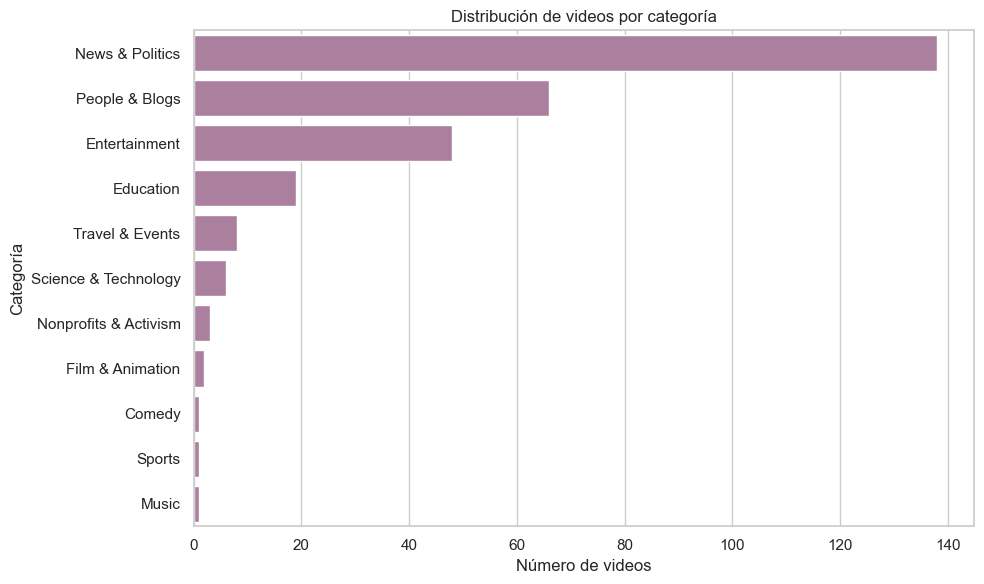

In [8]:
categorias = (
    videos["category"]
    .value_counts()
    .rename_axis("categoria")
    .reset_index(name="videos")
)

display(categorias)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=categorias,
    x="videos",
    y="categoria",
    color="#B279A2"
)

plt.title("Distribución de videos por categoría")
plt.xlabel("Número de videos")
plt.ylabel("Categoría")
plt.tight_layout()
plt.show()

,consulta,videos
0,Municipalidad de Guatemala,20
1,Gobierno de Guatemala,19
2,@GobiernodelaRepublicadeGuatema,18
3,@MunicipalidaddeGuatemala-1551,18
4,@GobiernodeGuatemala,17
5,guatemala noticias,16
6,Gobierno de la República de Guatemala,16
7,Ministerio de Comunicaciones Guatemala,16
8,Conred Guatemala,15
9,PMT Guatemala,15


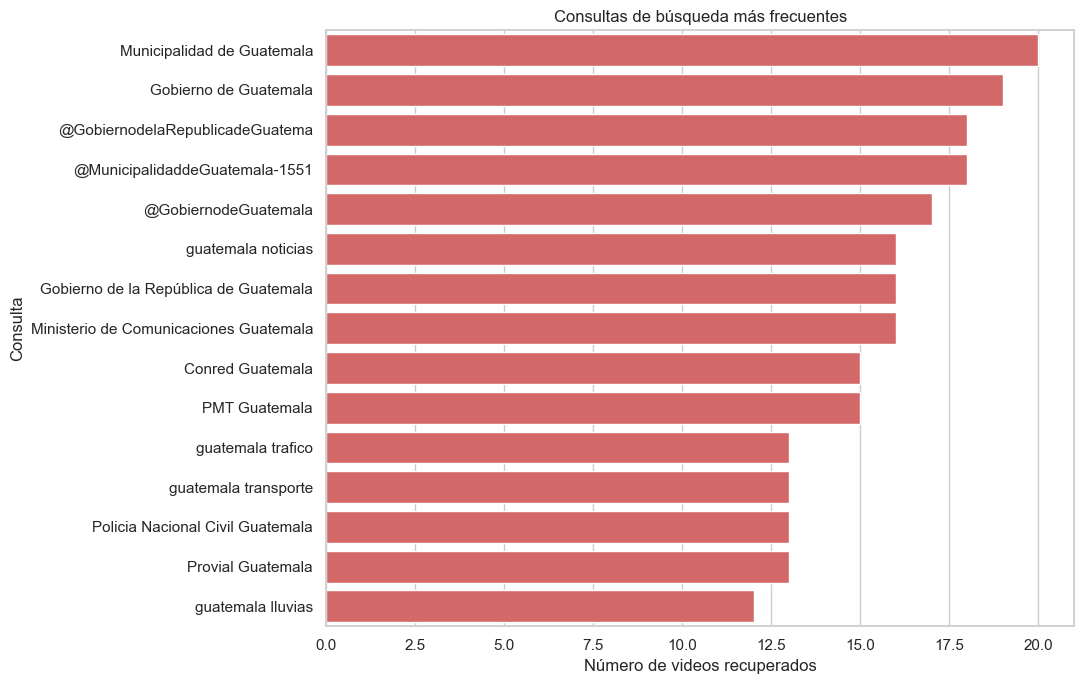

In [9]:
consultas = []

for valor in videos["query_hits"].fillna("[]"):
    try:
        lista = ast.literal_eval(valor)

        if isinstance(lista, list):
            consultas.extend(lista)
    except (ValueError, SyntaxError):
        pass

frecuencia_consultas = pd.DataFrame(
    Counter(consultas).most_common(),
    columns=["consulta", "videos"]
)

display(frecuencia_consultas)

plt.figure(figsize=(11, 7))

sns.barplot(
    data=frecuencia_consultas.head(15),
    x="videos",
    y="consulta",
    color="#E45756"
)

plt.title("Consultas de búsqueda más frecuentes")
plt.xlabel("Número de videos recuperados")
plt.ylabel("Consulta")
plt.tight_layout()
plt.show()

## Hashtags frecuentes

Hashtags en títulos y descripciones:


,hashtag,frecuencia
0,guatemala,48
1,larondagt,29
2,noticias,14
3,envivodca,12
4,nacionales,7
5,like,7
6,comenta,7
7,comparte,7
8,siguenos,7
9,protegeryservir,6


Hashtags en comentarios:


,hashtag,frecuencia
0,ineptobran,1


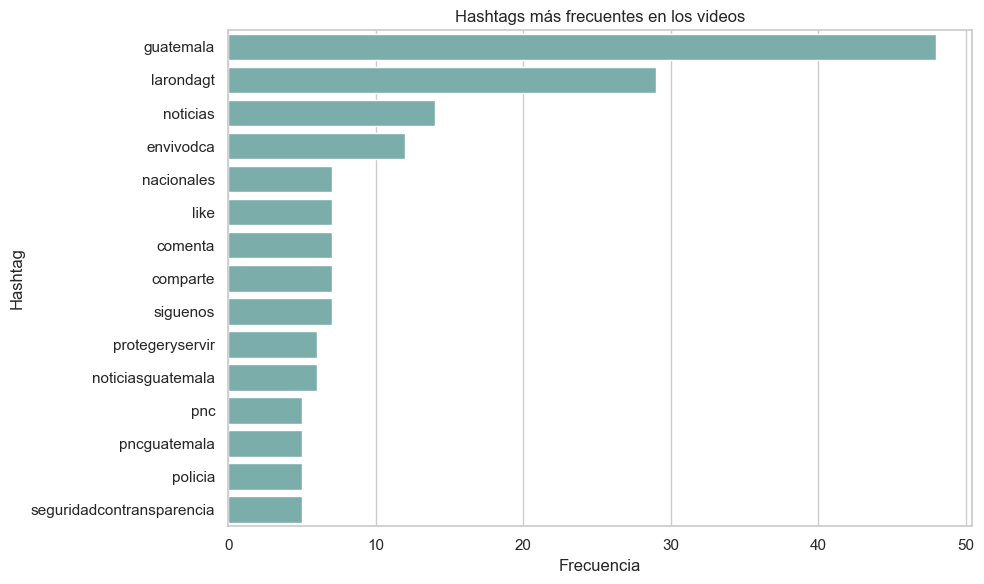

In [10]:
def extraer_hashtags(texto):
    return re.findall(
        r"(?<!\w)#([\wáéíóúñü]+)",
        str(texto).lower()
    )


hashtags_videos = []

texto_videos = (
    videos["title"].fillna("")
    + " "
    + videos["description"].fillna("")
)

for texto in texto_videos:
    hashtags_videos.extend(extraer_hashtags(texto))


hashtags_comentarios = []

for texto in comments["texto_original"].fillna(""):
    hashtags_comentarios.extend(extraer_hashtags(texto))


frecuencia_hashtags_videos = pd.DataFrame(
    Counter(hashtags_videos).most_common(20),
    columns=["hashtag", "frecuencia"]
)

frecuencia_hashtags_comentarios = pd.DataFrame(
    Counter(hashtags_comentarios).most_common(20),
    columns=["hashtag", "frecuencia"]
)

print("Hashtags en títulos y descripciones:")
display(frecuencia_hashtags_videos)

print("Hashtags en comentarios:")
display(frecuencia_hashtags_comentarios)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=frecuencia_hashtags_videos.head(15),
    x="frecuencia",
    y="hashtag",
    color="#72B7B2"
)

plt.title("Hashtags más frecuentes en los videos")
plt.xlabel("Frecuencia")
plt.ylabel("Hashtag")
plt.tight_layout()
plt.show()

## Palabras y bigramas frecuentes

In [11]:
STOPWORDS_ES = {
    "a", "al", "algo", "algunas", "algunos", "ante", "antes",
    "como", "con", "contra", "cual", "cuando", "de", "del",
    "desde", "donde", "durante", "e", "el", "ella", "ellas",
    "ellos", "en", "entre", "era", "eran", "eres", "es", "esa",
    "esas", "ese", "eso", "esos", "esta", "estaba", "estaban",
    "estado", "estamos", "estar", "estas", "este", "esto", "estos",
    "estoy", "fue", "fueron", "ha", "habia", "han", "hasta",
    "hay", "la", "las", "le", "les", "lo", "los", "mas", "me",
    "mi", "mis", "mucho", "muy", "nada", "ni", "no", "nos",
    "nosotros", "nuestra", "nuestro", "o", "otra", "otras", "otro",
    "otros", "para", "pero", "poco", "por", "porque", "que",
    "quien", "se", "sea", "ser", "si", "sin", "sobre", "son",
    "su", "sus", "tambien", "te", "tenia", "tiene", "tienen",
    "todo", "todos", "tu", "tus", "un", "una", "unas", "uno",
    "unos", "usted", "ustedes", "ya", "yo", "y"
}


def normalizar_tokens(texto):
    texto = str(texto).lower()

    texto = unicodedata.normalize("NFKD", texto)
    texto = texto.encode("ascii", "ignore").decode("utf-8")

    tokens = re.findall(r"[a-z]{3,}", texto)

    return [
        token
        for token in tokens
        if token not in STOPWORDS_ES
    ]


todas_palabras = []
todos_bigramas = []

for texto in comments["texto_limpio"].fillna(""):
    tokens = normalizar_tokens(texto)

    todas_palabras.extend(tokens)
    todos_bigramas.extend(
        zip(tokens, tokens[1:])
    )


frecuencia_palabras = pd.DataFrame(
    Counter(todas_palabras).most_common(25),
    columns=["palabra", "frecuencia"]
)

frecuencia_bigramas = pd.DataFrame(
    [
        (" ".join(bigrama), frecuencia)
        for bigrama, frecuencia
        in Counter(todos_bigramas).most_common(25)
    ],
    columns=["bigrama", "frecuencia"]
)

print("Palabras frecuentes:")
display(frecuencia_palabras)

print("Bigramas frecuentes:")
display(frecuencia_bigramas)

Palabras frecuentes:


,palabra,frecuencia
0,hacer,59
1,pueblo,56
2,pais,56
3,guatemala,52
4,diputado,51
5,bueno,40
6,solo,37
7,poder,36
8,pagar,36
9,presidente,35


Bigramas frecuentes:


,bigrama,frecuencia
0,bernardo arevalo,10
1,presidente bernardo,9
2,ciudad guatemala,6
3,buscar trabajo,5
4,nery roda,5
5,bla bla,5
6,pacto corrupto,5
7,pagar sueldo,5
8,vivar guatemala,4
9,gastar dinero,4


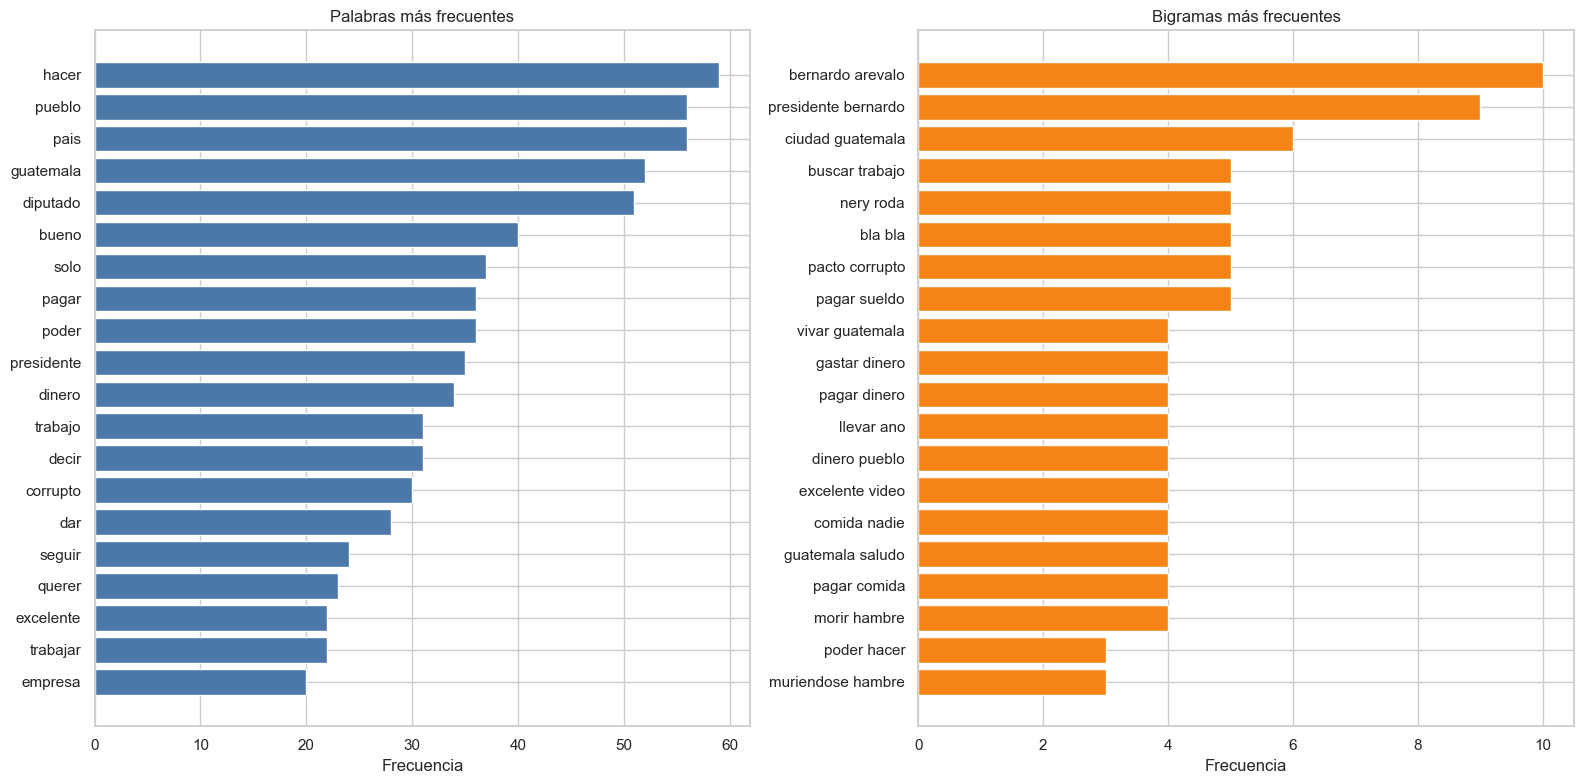

In [12]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 8)
)

datos_palabras = frecuencia_palabras.head(20).sort_values(
    "frecuencia"
)

datos_bigramas = frecuencia_bigramas.head(20).sort_values(
    "frecuencia"
)

axes[0].barh(
    datos_palabras["palabra"],
    datos_palabras["frecuencia"],
    color="#4C78A8"
)

axes[0].set_title("Palabras más frecuentes")
axes[0].set_xlabel("Frecuencia")
axes[0].set_ylabel("")

axes[1].barh(
    datos_bigramas["bigrama"],
    datos_bigramas["frecuencia"],
    color="#F58518"
)

axes[1].set_title("Bigramas más frecuentes")
axes[1].set_xlabel("Frecuencia")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## Concentración de comentarios

In [13]:
def tabla_concentracion(datos, columna="comentarios"):
    ordenados = (
        datos.sort_values(columna, ascending=False)
        .reset_index(drop=True)
        .copy()
    )

    ordenados["participacion"] = (
        ordenados[columna] / ordenados[columna].sum()
    )

    ordenados["participacion_acumulada"] = (
        ordenados["participacion"].cumsum()
    )

    return ordenados


concentracion_videos = tabla_concentracion(
    participacion_video
)

concentracion_canales = tabla_concentracion(
    participacion_canal
)


resumen_concentracion = pd.DataFrame({
    "grupo": [
        "Video principal",
        "3 videos principales",
        "5 videos principales",
        "10 videos principales",
        "Canal principal",
        "3 canales principales",
        "5 canales principales"
    ],
    "proporcion": [
        concentracion_videos.head(1)["comentarios"].sum()
        / comments["comment_id"].nunique(),

        concentracion_videos.head(3)["comentarios"].sum()
        / comments["comment_id"].nunique(),

        concentracion_videos.head(5)["comentarios"].sum()
        / comments["comment_id"].nunique(),

        concentracion_videos.head(10)["comentarios"].sum()
        / comments["comment_id"].nunique(),

        concentracion_canales.head(1)["comentarios"].sum()
        / comments["comment_id"].nunique(),

        concentracion_canales.head(3)["comentarios"].sum()
        / comments["comment_id"].nunique(),

        concentracion_canales.head(5)["comentarios"].sum()
        / comments["comment_id"].nunique()
    ]
})

resumen_concentracion["porcentaje"] = (
    resumen_concentracion["proporcion"]
    .map(lambda valor: f"{valor:.1%}")
)

display(
    resumen_concentracion[
        ["grupo", "porcentaje"]
    ]
)

,grupo,porcentaje
0,Video principal,39.7%
1,3 videos principales,63.1%
2,5 videos principales,75.4%
3,10 videos principales,93.6%
4,Canal principal,63.1%
5,3 canales principales,86.5%
6,5 canales principales,96.1%


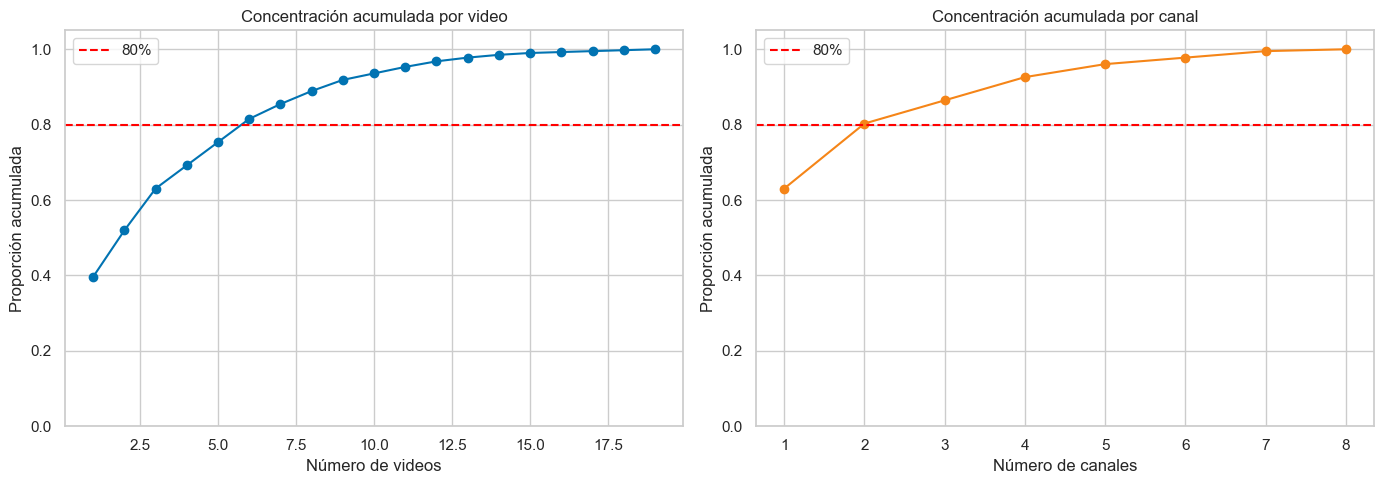

In [14]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 5)
)

axes[0].plot(
    np.arange(1, len(concentracion_videos) + 1),
    concentracion_videos["participacion_acumulada"],
    marker="o"
)

axes[0].axhline(
    0.80,
    color="red",
    linestyle="--",
    label="80%"
)

axes[0].set_title("Concentración acumulada por video")
axes[0].set_xlabel("Número de videos")
axes[0].set_ylabel("Proporción acumulada")
axes[0].set_ylim(0, 1.05)
axes[0].legend()


axes[1].plot(
    np.arange(1, len(concentracion_canales) + 1),
    concentracion_canales["participacion_acumulada"],
    marker="o",
    color="#F58518"
)

axes[1].axhline(
    0.80,
    color="red",
    linestyle="--",
    label="80%"
)

axes[1].set_title("Concentración acumulada por canal")
axes[1].set_xlabel("Número de canales")
axes[1].set_ylabel("Proporción acumulada")
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.tight_layout()
plt.show()

## Visualizacione sy comentarios por video

In [15]:
videos_participacion = videos[
    [
        "video_id",
        "title",
        "channel_name",
        "view_count"
    ]
].merge(
    participacion_video[
        [
            "video_id",
            "comentarios",
            "autores_unicos"
        ]
    ],
    on="video_id",
    how="left"
)

videos_participacion[
    ["comentarios", "autores_unicos"]
] = videos_participacion[
    ["comentarios", "autores_unicos"]
].fillna(0)

pearson_total = pearsonr(
    videos_participacion["view_count"],
    videos_participacion["comentarios"]
)

spearman_total = spearmanr(
    videos_participacion["view_count"],
    videos_participacion["comentarios"]
)

videos_observados = videos_participacion.query(
    "comentarios > 0"
).copy()

pearson_observados = pearsonr(
    videos_observados["view_count"],
    videos_observados["comentarios"]
)

spearman_observados = spearmanr(
    videos_observados["view_count"],
    videos_observados["comentarios"]
)


resultados_correlacion = pd.DataFrame({
    "conjunto": [
        "Todos los videos",
        "Videos con comentarios recolectados"
    ],
    "n": [
        len(videos_participacion),
        len(videos_observados)
    ],
    "pearson_r": [
        pearson_total.statistic,
        pearson_observados.statistic
    ],
    "pearson_p": [
        pearson_total.pvalue,
        pearson_observados.pvalue
    ],
    "spearman_r": [
        spearman_total.statistic,
        spearman_observados.statistic
    ],
    "spearman_p": [
        spearman_total.pvalue,
        spearman_observados.pvalue
    ]
})

display(resultados_correlacion.round(4))

,conjunto,n,pearson_r,pearson_p,spearman_r,spearman_p
0,Todos los videos,293,-0.0084,0.8862,0.0803,0.1703
1,Videos con comentarios recolectados,19,0.0669,0.7856,0.8115,0.0000


## Dispersión de popularidad y participación

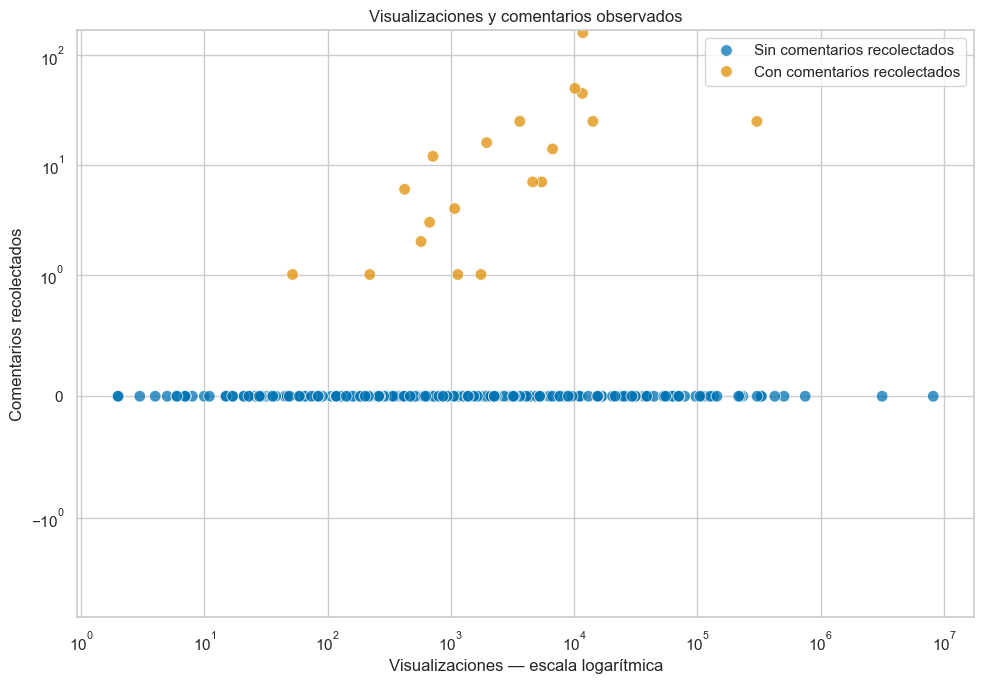

In [16]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=videos_participacion,
    x="view_count",
    y="comentarios",
    hue=np.where(
        videos_participacion["comentarios"] > 0,
        "Con comentarios recolectados",
        "Sin comentarios recolectados"
    ),
    alpha=0.75,
    s=70
)

plt.xscale("log")
plt.yscale("symlog", linthresh=1)

plt.title("Visualizaciones y comentarios observados")
plt.xlabel("Visualizaciones — escala logarítmica")
plt.ylabel("Comentarios recolectados")
plt.legend(title="")
plt.tight_layout()
plt.show()

## Audiencias compartidas

In [17]:
autor_video = comments[
    [
        "author_channel_id",
        "author_name",
        "video_id",
        "video_title",
        "channel_id",
        "channel_name"
    ]
].drop_duplicates()


actividad_autores = (
    autor_video.groupby("author_channel_id")
    .agg(
        autor=("author_name", "first"),
        videos=("video_id", "nunique"),
        canales=("channel_id", "nunique"),
        nombres_videos=(
            "video_title",
            lambda valores: " | ".join(pd.unique(valores))
        ),
        nombres_canales=(
            "channel_name",
            lambda valores: " | ".join(pd.unique(valores))
        )
    )
    .reset_index()
    .sort_values(
        ["canales", "videos"],
        ascending=False
    )
)


autores_multivideo = actividad_autores.query(
    "videos > 1"
)

autores_multicanal = actividad_autores.query(
    "canales > 1"
)


print(
    f"Autores que comentaron en más de un video: "
    f"{len(autores_multivideo)} "
    f"({len(autores_multivideo) / comments['author_channel_id'].nunique():.1%})"
)

print(
    f"Autores que comentaron en más de un canal: "
    f"{len(autores_multicanal)} "
    f"({len(autores_multicanal) / comments['author_channel_id'].nunique():.1%})"
)

print("\nAutores puente entre canales:")
display(
    autores_multicanal[
        [
            "autor",
            "videos",
            "canales",
            "nombres_canales",
            "nombres_videos"
        ]
    ]
)

Autores que comentaron en más de un video: 9 (2.7%)
Autores que comentaron en más de un canal: 4 (1.2%)

Autores puente entre canales:


,autor,videos,canales,nombres_canales,nombres_videos
98,@virgiliogarcia3039,2,2,Quorum | Gobierno de la República de Guatemala,Qué rico come tu diputado | Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt
211,@MarcosCarillo-b1r,2,2,Quorum | TN23 Guatemala,La cooptación de Walter Mazariegos en la USAC | Capturan a ladrón que había quedado gr...
250,@franciscoflores3120,2,2,Gobierno de la República de Guatemala | Noti7,Inician los trabajos de recuperación del Puente Belice II. | Capturan a presuntos deli...
287,@moisesvaldez4043,2,2,Quorum | PrensaLibreOficial,Qué rico come tu diputado | Bloqueos en Guatemala este 31 de agosto por alza en combus...


## Videos con autores compartidos

In [18]:
pares_videos = []

for autor, grupo in autor_video.groupby("author_channel_id"):
    videos_autor = sorted(
        grupo["video_id"].unique()
    )

    for video_1, video_2 in combinations(videos_autor, 2):
        pares_videos.append((video_1, video_2))


conteo_pares = Counter(pares_videos)

audiencia_compartida = pd.DataFrame(
    [
        {
            "video_id_1": video_1,
            "video_id_2": video_2,
            "autores_compartidos": cantidad
        }
        for (video_1, video_2), cantidad
        in conteo_pares.items()
    ]
)


titulos = videos.set_index("video_id")["title"].to_dict()

if not audiencia_compartida.empty:
    audiencia_compartida["video_1"] = (
        audiencia_compartida["video_id_1"].map(titulos)
    )

    audiencia_compartida["video_2"] = (
        audiencia_compartida["video_id_2"].map(titulos)
    )

    audiencia_compartida = audiencia_compartida.sort_values(
        "autores_compartidos",
        ascending=False
    )

    display(
        audiencia_compartida[
            [
                "video_1",
                "video_2",
                "autores_compartidos"
            ]
        ].head(15)
    )
else:
    print("No se encontraron autores compartidos entre videos.")

,video_1,video_2,autores_compartidos
1,Internet: escoger el menos malo,Arroz con pollo a la MONOPOLIO,2
4,La cooptación de Walter Mazariegos en la USAC,Qué rico come tu diputado,2
0,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,Qué rico come tu diputado,1
2,Capturan a ladrón que había quedado grabado mientras robaba en una parroquia de Retalh...,La cooptación de Walter Mazariegos en la USAC,1
3,Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer asalto,Inician los trabajos de recuperación del Puente Belice II.,1
5,La cooptación de Walter Mazariegos en la USAC,Internet: escoger el menos malo,1
6,Qué rico come tu diputado,Internet: escoger el menos malo,1
7,Bloqueos en Guatemala este 31 de agosto por alza en combustibles afectan rutas princip...,Qué rico come tu diputado,1
8,Caminar en una ciudad hecha para carros,Internet: escoger el menos malo,1
9,Caminar en una ciudad hecha para carros,Arroz con pollo a la MONOPOLIO,1


## Comentarios por visualizaciones

In [19]:
participacion_video["comentarios_por_1000_vistas"] = (
    participacion_video["comentarios"]
    / participacion_video["view_count"]
    * 1000
)

participacion_relativa = (
    participacion_video.query("comentarios >= 5")
    .sort_values(
        "comentarios_por_1000_vistas",
        ascending=False
    )
)

display(
    participacion_relativa[
        [
            "video_title",
            "channel_name",
            "view_count",
            "comentarios",
            "comentarios_por_1000_vistas"
        ]
    ].head(10)
)

,video_title,channel_name,view_count,comentarios,comentarios_por_1000_vistas
15,Internet: escoger el menos malo,Quorum,717,12,16.736402
8,Caminar en una ciudad hecha para carros,Quorum,422,6,14.218009
14,Qué rico come tu diputado,Quorum,11775,161,13.673036
17,Arroz con pollo a la MONOPOLIO,Quorum,1954,16,8.188332
5,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,Gobierno de la República de Guatemala,3628,25,6.890849
12,La cooptación de Walter Mazariegos en la USAC,Quorum,10156,50,4.923198
2,Inician los trabajos de recuperación del Puente Belice II.,Gobierno de la República de Guatemala,11670,45,3.856041
0,Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer asalto,Noti7,6692,14,2.092050
4,EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticia...,Noticias Telemundo,14200,25,1.760563
11,Capturan a ladrón que había quedado grabado mientras robaba en una parroquia de Retalh...,TN23 Guatemala,4616,7,1.516464


## Respuestas por comentario

In [20]:
participacion_video["respuestas_por_comentario"] = (
    participacion_video["respuestas"]
    / participacion_video["comentarios"]
)

display(
    participacion_video.sort_values(
        "respuestas_por_comentario",
        ascending=False
    )[
        [
            "video_title",
            "comentarios",
            "respuestas",
            "respuestas_por_comentario"
        ]
    ].head(10)
)

,video_title,comentarios,respuestas,respuestas_por_comentario
13,Plan 2032 Ciudad de Guatemala,25,16,0.640000
4,EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticia...,25,13,0.520000
2,Inician los trabajos de recuperación del Puente Belice II.,45,11,0.244444
5,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,25,4,0.160000
10,Bloqueos en Guatemala este 31 de agosto por alza en combustibles afectan rutas princip...,7,1,0.142857
11,Capturan a ladrón que había quedado grabado mientras robaba en una parroquia de Retalh...,7,1,0.142857
15,Internet: escoger el menos malo,12,1,0.083333
0,Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer asalto,14,1,0.071429
14,Qué rico come tu diputado,161,3,0.018634
12,La cooptación de Walter Mazariegos en la USAC,50,0,0.000000


## Concentración de me gusta

In [21]:
participacion_video["proporcion_me_gusta"] = (
    participacion_video["me_gusta"]
    / participacion_video["me_gusta"].sum()
)

display(
    participacion_video.sort_values(
        "me_gusta",
        ascending=False
    )[
        [
            "video_title",
            "channel_name",
            "comentarios",
            "me_gusta",
            "proporcion_me_gusta"
        ]
    ].head(10)
)

video_mas_gustado = participacion_video.sort_values(
    "me_gusta",
    ascending=False
).iloc[0]

print(
    f"'{video_mas_gustado['video_title']}' concentra "
    f"{video_mas_gustado['proporcion_me_gusta']:.1%} "
    f"de los me gusta registrados."
)

,video_title,channel_name,comentarios,me_gusta,proporcion_me_gusta
13,Plan 2032 Ciudad de Guatemala,Municipalidad de Guatemala,25,1697,0.729892
14,Qué rico come tu diputado,Quorum,161,358,0.153978
12,La cooptación de Walter Mazariegos en la USAC,Quorum,50,91,0.039140
2,Inician los trabajos de recuperación del Puente Belice II.,Gobierno de la República de Guatemala,45,90,0.038710
4,EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticia...,Noticias Telemundo,25,25,0.010753
5,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,Gobierno de la República de Guatemala,25,20,0.008602
17,Arroz con pollo a la MONOPOLIO,Quorum,16,13,0.005591
0,Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer asalto,Noti7,14,12,0.005161
6,"I’x K’at: el primer equipo guatemalteco de pelota maya, conformado únicamente por muje...",Quorum,4,8,0.003441
3,10 Preguntas a un año del Paro Nacional,Quorum,3,4,0.001720


'Plan 2032 Ciudad de Guatemala' concentra 73.0% de los me gusta registrados.


## Resumen de hallazgos

In [22]:
video_principal = participacion_video.iloc[0]
canal_principal = participacion_canal.iloc[0]

print("HALLAZGOS PRINCIPALES\n")

print(
    f"1. El video con mayor participación es "
    f"'{video_principal['video_title']}', con "
    f"{video_principal['comentarios']} comentarios y "
    f"{video_principal['autores_unicos']} autores únicos."
)

print(
    f"2. Este video concentra "
    f"{video_principal['comentarios'] / len(comments):.1%} "
    f"de los comentarios recolectados."
)

print(
    f"3. El canal con mayor participación es "
    f"{canal_principal['channel_name']}, con "
    f"{canal_principal['comentarios']} comentarios, equivalentes a "
    f"{canal_principal['porcentaje_comentarios']:.1%} del total."
)

print(
    f"4. Solamente {comments['video_id'].nunique()} de "
    f"{videos['video_id'].nunique()} videos tienen comentarios "
    f"recolectados."
)

print(
    f"5. La correlación de Spearman en todos los videos es "
    f"{spearman_total.statistic:.3f}, con p = "
    f"{spearman_total.pvalue:.3f}."
)

print(
    f"6. Entre los videos con comentarios recolectados, "
    f"la correlación de Spearman es "
    f"{spearman_observados.statistic:.3f}, con p = "
    f"{spearman_observados.pvalue:.4f}."
)

print(
    f"7. Se identificaron {len(autores_multivideo)} autores que "
    f"participaron en más de un video y "
    f"{len(autores_multicanal)} que participaron en más de un canal."
)

HALLAZGOS PRINCIPALES

1. El video con mayor participación es 'Qué rico come tu diputado', con 161 comentarios y 128 autores únicos.
2. Este video concentra 39.7% de los comentarios recolectados.
3. El canal con mayor participación es Quorum, con 256 comentarios, equivalentes a 63.1% del total.
4. Solamente 19 de 293 videos tienen comentarios recolectados.
5. La correlación de Spearman en todos los videos es 0.080, con p = 0.170.
6. Entre los videos con comentarios recolectados, la correlación de Spearman es 0.811, con p = 0.0000.
7. Se identificaron 9 autores que participaron en más de un video y 4 que participaron en más de un canal.
